# Verification: AFOLU Fluxes from Gridded Extension

Read the gridded extension output (from notebook 03) and recompute AFOLU CO₂ fluxes
using the same cohort-based model calibrated in notebook 02. Confirm that the implied
fluxes match the IAM target trajectory.

This closes the loop:
- **Notebook 02**: Calibrate model → derive AFOLU-consistent ramp $r(t)$
- **Notebook 03**: Apply $r(t)$ to produce gridded extension files
- **Notebook 04** (this): Read gridded files → recompute fluxes → verify match

In [35]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

from src import config as cfg
from src.data import (
    load_csv, filter_scenario, get_variable,
    load_states,
)
from src import carbon_model as cm

# ── Scenario selector (change this to switch scenarios) ──
SCENARIO_KEY = "H"      # "VL" | "H" | ...
sc = cfg.get_scenario(SCENARIO_KEY)
print(f"Scenario: {sc.key} — {sc.model} / {sc.scenario}")
print(f"State vars: {sc.state_vars}")
print(f"Output dir: {sc.output_dir}")

%matplotlib inline
plt.rcParams['figure.figsize'] = (14, 5)

Scenario: H — GCAM 8s / SSP3 - High Emissions
State vars: ['forest', 'c3ann', 'c3nfx', 'c3per', 'c4ann', 'c4per', 'pastr', 'range', 'urban']
Output dir: /div/no-backup-nac/users/bensan/extend-luh/output/H


## 1. Load IAM Target and Calibration Parameters

In [36]:
df = load_csv()
sc_data = filter_scenario(df, scen=sc)
afolu_target = get_variable(sc_data, 'Emissions|CO2|AFOLU')

# Load calibration parameters from notebook 02
cal = np.load(sc.output_dir / 'afolu_calibration.npz')
tau_opt = float(cal['tau'])
beta = float(cal['beta'])
gamma = float(cal['gamma'])
alpha_trans = float(cal['alpha_trans'])
alpha_stock = float(cal['alpha_stock'])
r_derived = cal['ramp']
ext_years = cal['years']

print(f'Calibration: τ={tau_opt:.0f} yr, β={beta:.1f}, γ={gamma:.0f}/decade')
print(f'             α_trans={alpha_trans:.3f}, α_stock={alpha_stock:.3f}')
print(f'Ramp: {ext_years[0]}–{ext_years[-1]}, range [{r_derived.min():.4f}, {r_derived.max():.4f}]')

Calibration: τ=20 yr, β=2243.0, γ=-355/decade
             α_trans=0.369, α_stock=0.612
Ramp: 2101–2500, range [0.0000, 0.8016]


## 2. Load Gridded Data

Open the extension output from notebook 03 and the original input for the pre-2100 period.

In [37]:
# Find the states extension file
import glob
ext_files = sorted(glob.glob(str(sc.output_dir / '*_extension_transient_2101-*.nc')))
states_ext_file = [f for f in ext_files if 'states' in f.lower() or 'step4' in f.lower()
                   or 'timeseries' in f.lower()]
if not states_ext_file:
    raise FileNotFoundError(f'No states extension file in {sc.output_dir}')
states_ext_file = states_ext_file[0]
print(f'Extension file: {os.path.basename(states_ext_file)}')

ds_ext = xr.open_dataset(states_ext_file)
ds_input = load_states(scen=sc)

lat = ds_ext.lat.values
lon = ds_ext.lon.values
ramp_years = ds_ext.time.values.astype(int)

# Grid-cell area (km²)
R_EARTH = 6371.0
dlat = np.abs(np.diff(lat[:2]))[0]
dlon = np.abs(np.diff(lon[:2]))[0]
lat_rad = np.deg2rad(lat)
cell_area = (R_EARTH**2) * np.deg2rad(dlat) * np.deg2rad(dlon) * np.cos(lat_rad)
cell_area_2d = np.broadcast_to(cell_area[:, np.newaxis], (len(lat), len(lon)))

print(f'Extension: {ramp_years[0]}–{ramp_years[-1]} ({len(ramp_years)} years)')
print(f'Grid: {len(lat)} × {len(lon)}')

Extension file: annual_timeseries_v3_nan0_extension_transient_2101-2142.nc
Extension: 2101–2142 (42 years)
Grid: 720 × 1440


## 3. Carbon Density Parameters

Same values as notebook 02 — these must match for the verification to be meaningful.

In [38]:
# Import carbon cycle parameters from the model module
CARBON_DENSITY = cm.CARBON_DENSITY
C_EQ = cm.C_EQ
REGROW_VARS = cm.regrow_vars_for(sc.state_vars)
TC_TO_MTCO2 = cm.TC_TO_MTCO2

print(f'Regrowing types: {REGROW_VARS}')

Regrowing types: ['forest']


## 4. Compute AFOLU Fluxes from Gridded Extension

Read the actual gridded extension fields and compute transition and stock-change fluxes.
This is the independent check — we use the gridded data, not the analytical forward solve.

In [39]:
%%time
# ─── Pre-2100: transition flux and area increments ───
input_years = ds_input.time.values.astype(int)
n_input = len(input_years)
input_flux_years = input_years[1:]
n_pre = len(input_flux_years)

# Time trend (must match notebook 02 exactly)
time_trend_pre = (input_flux_years - input_flux_years.mean()) / 10.0
time_2100 = (2100 - input_flux_years.mean()) / 10.0

transition_flux_pre = np.zeros(n_pre)
area_incr_pre = {v: np.zeros(n_pre) for v in REGROW_VARS}

for ti in range(1, n_input):
    af = 0.0
    for v in sc.state_vars:
        delta = ds_input[v].isel(time=ti).values - ds_input[v].isel(time=ti-1).values
        af += np.nansum(-delta * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2
    transition_flux_pre[ti-1] = af
    for v in REGROW_VARS:
        delta = ds_input[v].isel(time=ti).values - ds_input[v].isel(time=ti-1).values
        area_incr_pre[v][ti-1] = np.nansum(delta * cell_area_2d)

# ─── Extension period: transition flux and area increments ───
vals_2100 = {v: ds_input[v].isel(time=-1).values for v in sc.state_vars}
n_ramp = len(ramp_years)
full_ext_years = np.arange(cfg.YR_END_INPUT + 1, cfg.YR_END_OUTPUT + 1)
n_ext = len(full_ext_years)

ext_transition = np.zeros(n_ext)
area_incr_ext = {v: np.zeros(n_ext) for v in REGROW_VARS}

for ti in range(n_ramp):
    af = 0.0
    for v in sc.state_vars:
        prev = vals_2100[v] if ti == 0 else ds_ext[v].isel(time=ti-1).values
        curr = ds_ext[v].isel(time=ti).values
        delta = curr - prev
        af += np.nansum(-delta * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2
    ext_transition[ti] = af
    for v in REGROW_VARS:
        prev = vals_2100[v] if ti == 0 else ds_ext[v].isel(time=ti-1).values
        curr = ds_ext[v].isel(time=ti).values
        area_incr_ext[v][ti] = np.nansum((curr - prev) * cell_area_2d)

# ─── Stock-change flux via cohort convolution ───
decay = np.exp(-1.0 / tau_opt)
stock_flux_pre = np.zeros(n_pre)
G_state = {v: 0.0 for v in REGROW_VARS}

for t in range(n_pre):
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0:
            continue
        G_state[v] = G_state[v] * decay + area_incr_pre[v][t]
        stock_flux_pre[t] += -(ceq / tau_opt) * G_state[v] * TC_TO_MTCO2

ext_stock = np.zeros(n_ext)
for t in range(n_ext):
    for v in REGROW_VARS:
        ceq = C_EQ[v]
        if ceq == 0:
            continue
        G_state[v] = G_state[v] * decay + area_incr_ext[v][t]
        ext_stock[t] += -(ceq / tau_opt) * G_state[v] * TC_TO_MTCO2

# ─── Calibrated total (Model D: β + γ·t + α_trans·F_trans + α_stock·F_stock) ───
ramp_for_ext = np.zeros(n_ext)
ramp_for_ext[:len(r_derived)] = r_derived[:n_ext]

# Pre-2100: full 4-predictor model
calibrated_pre = (beta + gamma * time_trend_pre
                  + alpha_trans * transition_flux_pre
                  + alpha_stock * stock_flux_pre)

# Post-2100: baseline frozen at β + γ·t₂₁₀₀ (matches notebook 02 forward solve)
baseline = beta + gamma * time_2100
ext_calib = (baseline * ramp_for_ext
             + alpha_trans * ext_transition
             + alpha_stock * ext_stock)

print(f'Pre-2100: {n_pre} years, Extension: {n_ext} years')
print(f'Baseline (β + γ·t₂₁₀₀) = {baseline:.0f} Mt CO₂/yr')
print(f'Transition flux range (ext): [{ext_transition.min():.0f}, {ext_transition.max():.0f}]')
print(f'Stock flux range (ext): [{ext_stock.min():.0f}, {ext_stock.max():.0f}]')

Pre-2100: 76 years, Extension: 400 years
Baseline (β + γ·t₂₁₀₀) = 912 Mt CO₂/yr
Transition flux range (ext): [0, 1008]
Stock flux range (ext): [0, 894]
CPU times: user 11.7 s, sys: 1.67 s, total: 13.4 s
Wall time: 13.5 s


## 5. Verification: Gridded Fluxes vs IAM Target

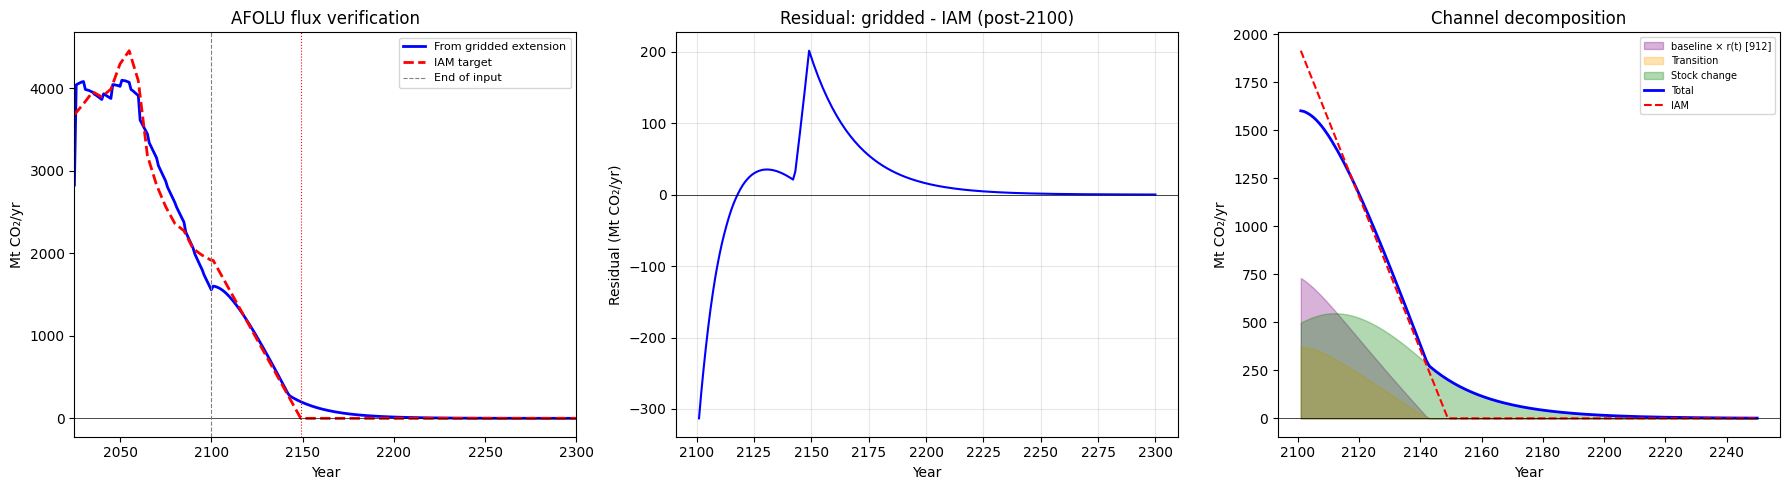


Post-2100 verification (during ramp):
  RMSE: 104.6 Mt CO₂/yr
  Max |residual|: 313.1 Mt CO₂/yr
  WARN: large residuals


In [40]:
# Full timeseries
all_years = np.concatenate([input_flux_years, full_ext_years])
all_calib = np.concatenate([calibrated_pre, ext_calib])

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Left: full timeseries
ax = axes[0]
ax.plot(all_years, all_calib, 'b-', lw=2, label='From gridded extension')
afolu_plot = afolu_target.loc[2025:2300]
ax.plot(afolu_plot.index, afolu_plot.values, 'r--', lw=2, label='IAM target')
ax.axhline(0, color='k', lw=0.5)
ax.axvline(cfg.YR_END_INPUT, color='gray', ls='--', lw=0.8, label='End of input')
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('AFOLU flux verification')
ax.legend(fontsize=8); ax.set_xlim(2025, 2300)

# Middle: residual post-2100
ax = axes[1]
iam_ext_vals = np.array([afolu_target.loc[yr] if yr in afolu_target.index else 0.0
                          for yr in full_ext_years])
residual = ext_calib - iam_ext_vals
ax.plot(full_ext_years[:200], residual[:200], 'b-', lw=1.5)
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Residual (Mt CO₂/yr)')
ax.set_title('Residual: gridded - IAM (post-2100)')
ax.grid(True, alpha=0.3)

# Right: channel decomposition (baseline = β + γ·t₂₁₀₀, frozen post-2100)
ax = axes[2]
baseline_comp = baseline * ramp_for_ext
trans_comp = alpha_trans * ext_transition
stock_comp = alpha_stock * ext_stock
ax.fill_between(full_ext_years[:150], 0, baseline_comp[:150],
                alpha=0.3, color='purple', label=f'baseline × r(t) [{baseline:.0f}]')
ax.fill_between(full_ext_years[:150], 0, trans_comp[:150],
                alpha=0.3, color='orange', label='Transition')
ax.fill_between(full_ext_years[:150], 0, stock_comp[:150],
                alpha=0.3, color='green', label='Stock change')
ax.plot(full_ext_years[:150], ext_calib[:150], 'b-', lw=2, label='Total')
ax.plot(full_ext_years[:150], iam_ext_vals[:150], 'r--', lw=1.5, label='IAM')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('Channel decomposition')
ax.legend(fontsize=7)

plt.tight_layout(); plt.show()

# Quantitative check
ramp_mask = full_ext_years <= cfg.YR_AFOLU_ZERO
rmse_ramp = np.sqrt(np.mean(residual[ramp_mask]**2))
max_resid = np.max(np.abs(residual[ramp_mask]))
print(f'\nPost-2100 verification (during ramp):')
print(f'  RMSE: {rmse_ramp:.1f} Mt CO₂/yr')
print(f'  Max |residual|: {max_resid:.1f} Mt CO₂/yr')
print(f'  PASS' if rmse_ramp < 100 else f'  WARN: large residuals')

=== AFOLU at the 2100 boundary ===
  IAM target @ 2100:       1915.0 Mt CO₂/yr
  Calibrated @ 2100:       1556.9 Mt CO₂/yr
  Extension  @ 2101:       1601.9 Mt CO₂/yr
  Jump (2101 - 2100 cal):  45.0 Mt CO₂/yr

=== Pre-2100 decomposition (last year) ===
  β                     = 2243.0
  γ·t(2100)            = -1331.1
  α_trans·F_trans       = 155.0
  α_stock·F_stock       = 490.0
  Sum                   = 1556.9

=== Post-2100 decomposition (2101) ===
  baseline × r(2101)    = 731.0  (baseline=911.9, r=0.8016)
  α_trans·F_trans(2101) = 372.4  (F_trans=1007.8)
  α_stock·F_stock(2101) = 498.5  (F_stock=814.0)
  Sum                   = 1601.9

=== Baseline continuity ===
  Pre-2100 baseline @ 2100:  β + γ·t₂₁₀₀ = 911.9
  Post-2100 baseline @ 2101: baseline × r(2101) = 731.0
  If r(2101)=1 it would be:  911.9
  r(2101) = 0.801629

=== Transition flux continuity ===
  Pre:  F_trans last = 419.6 Mt CO₂/yr
  Post: F_trans(2101) = 1007.8 Mt CO₂/yr (= gridded delta × C_dens)
  Ratio: 2.4017  (e

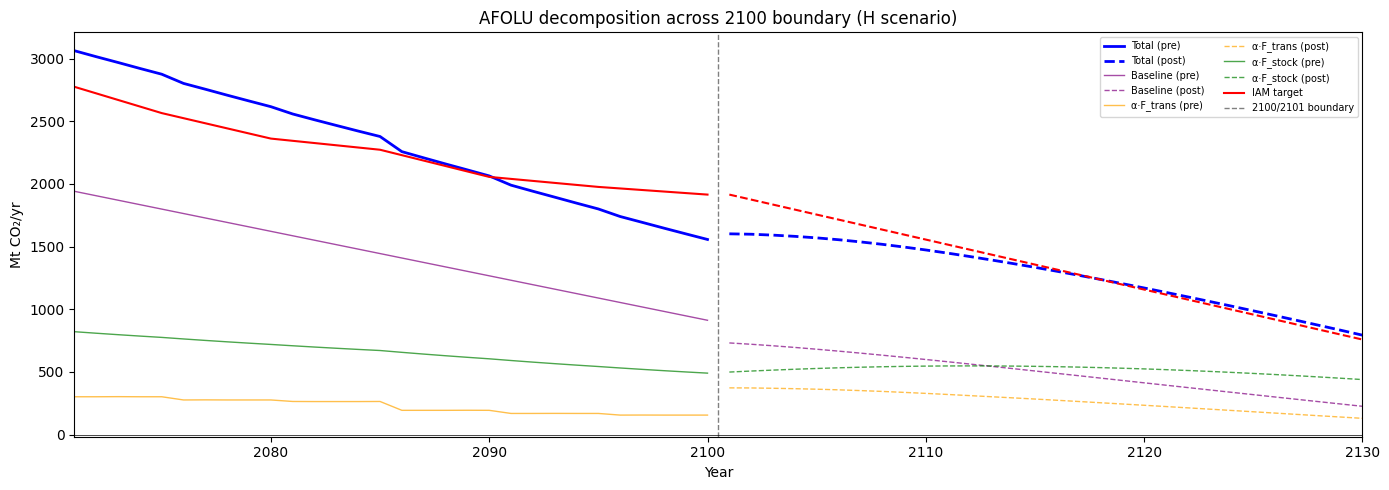

In [42]:
# ── Diagnostic: understand the 2100 jump ──
# Compare the last pre-2100 AFOLU value to the first post-2100 value,
# and decompose into the three channels.

# Last pre-2100 values
afolu_pre_last = calibrated_pre[-1]
afolu_2100_iam = afolu_target.loc[2100]
afolu_post_first = ext_calib[0]

print("=== AFOLU at the 2100 boundary ===")
print(f"  IAM target @ 2100:       {afolu_2100_iam:.1f} Mt CO₂/yr")
print(f"  Calibrated @ 2100:       {afolu_pre_last:.1f} Mt CO₂/yr")
print(f"  Extension  @ 2101:       {afolu_post_first:.1f} Mt CO₂/yr")
print(f"  Jump (2101 - 2100 cal):  {afolu_post_first - afolu_pre_last:.1f} Mt CO₂/yr")
print()

# Pre-2100 components at last year
t_last = time_trend_pre[-1]
print("=== Pre-2100 decomposition (last year) ===")
print(f"  β                     = {beta:.1f}")
print(f"  γ·t({input_flux_years[-1]})            = {gamma * t_last:.1f}")
print(f"  α_trans·F_trans       = {alpha_trans * transition_flux_pre[-1]:.1f}")
print(f"  α_stock·F_stock       = {alpha_stock * stock_flux_pre[-1]:.1f}")
print(f"  Sum                   = {beta + gamma*t_last + alpha_trans*transition_flux_pre[-1] + alpha_stock*stock_flux_pre[-1]:.1f}")
print()

# Post-2100 components at first year
print("=== Post-2100 decomposition (2101) ===")
print(f"  baseline × r(2101)    = {baseline * ramp_for_ext[0]:.1f}  (baseline={baseline:.1f}, r={ramp_for_ext[0]:.4f})")
print(f"  α_trans·F_trans(2101) = {alpha_trans * ext_transition[0]:.1f}  (F_trans={ext_transition[0]:.1f})")
print(f"  α_stock·F_stock(2101) = {alpha_stock * ext_stock[0]:.1f}  (F_stock={ext_stock[0]:.1f})")
print(f"  Sum                   = {baseline*ramp_for_ext[0] + alpha_trans*ext_transition[0] + alpha_stock*ext_stock[0]:.1f}")
print()

# The key question: how does the baseline term change?
# Pre-2100: β + γ·t (where t changes each year)
# Post-2100: (β + γ·t₂₁₀₀) × r(t)
# At 2100: pre-model = β + γ·t₂₁₀₀  (same as baseline)
# At 2101: post-model = baseline × r(2101)
print("=== Baseline continuity ===")
print(f"  Pre-2100 baseline @ 2100:  β + γ·t₂₁₀₀ = {beta + gamma * time_2100:.1f}")
print(f"  Post-2100 baseline @ 2101: baseline × r(2101) = {baseline * ramp_for_ext[0]:.1f}")
print(f"  If r(2101)=1 it would be:  {baseline:.1f}")
print(f"  r(2101) = {ramp_for_ext[0]:.6f}")
print()

# Transition flux continuity
print("=== Transition flux continuity ===")
print(f"  Pre:  F_trans last = {transition_flux_pre[-1]:.1f} Mt CO₂/yr")
print(f"  Post: F_trans(2101) = {ext_transition[0]:.1f} Mt CO₂/yr (= gridded delta × C_dens)")
print(f"  Ratio: {ext_transition[0]/transition_flux_pre[-1]:.4f}  (expect ~r(2101)={ramp_for_ext[0]:.4f})")
print()

# Stock flux continuity
print("=== Stock flux continuity ===")
print(f"  Pre:  F_stock last = {stock_flux_pre[-1]:.1f} Mt CO₂/yr")
print(f"  Post: F_stock(2101) = {ext_stock[0]:.1f} Mt CO₂/yr")
print(f"  Change: {ext_stock[0] - stock_flux_pre[-1]:.1f} Mt CO₂/yr")
print()

# Show the first 30 years of the decomposition
fig, ax = plt.subplots(figsize=(14, 5))
yrs_pre_plot = input_flux_years[-30:]
yrs_post_plot = full_ext_years[:30]

# Pre-2100 components (last 30 years)
pre_baseline = beta + gamma * time_trend_pre[-30:]
pre_trans = alpha_trans * transition_flux_pre[-30:]
pre_stock = alpha_stock * stock_flux_pre[-30:]

# Post-2100 components (first 30 years)
post_baseline = baseline * ramp_for_ext[:30]
post_trans = alpha_trans * ext_transition[:30]
post_stock = alpha_stock * ext_stock[:30]

ax.plot(yrs_pre_plot, calibrated_pre[-30:], 'b-', lw=2, label='Total (pre)')
ax.plot(yrs_post_plot, ext_calib[:30], 'b--', lw=2, label='Total (post)')
ax.plot(yrs_pre_plot, pre_baseline, 'purple', ls='-', lw=1, alpha=0.7, label='Baseline (pre)')
ax.plot(yrs_post_plot, post_baseline, 'purple', ls='--', lw=1, alpha=0.7, label='Baseline (post)')
ax.plot(yrs_pre_plot, pre_trans, 'orange', ls='-', lw=1, alpha=0.7, label='α·F_trans (pre)')
ax.plot(yrs_post_plot, post_trans, 'orange', ls='--', lw=1, alpha=0.7, label='α·F_trans (post)')
ax.plot(yrs_pre_plot, pre_stock, 'green', ls='-', lw=1, alpha=0.7, label='α·F_stock (pre)')
ax.plot(yrs_post_plot, post_stock, 'green', ls='--', lw=1, alpha=0.7, label='α·F_stock (post)')

# IAM target
iam_pre = afolu_target.loc[yrs_pre_plot[0]:yrs_pre_plot[-1]]
iam_post = np.array([afolu_target.loc[yr] if yr in afolu_target.index else 0.0 for yr in yrs_post_plot])
ax.plot(iam_pre.index, iam_pre.values, 'r-', lw=1.5, label='IAM target')
ax.plot(yrs_post_plot, iam_post, 'r--', lw=1.5)

ax.axvline(2100.5, color='gray', ls='--', lw=1, label='2100/2101 boundary')
ax.axhline(0, color='k', lw=0.5)
ax.set_xlabel('Year'); ax.set_ylabel('Mt CO₂/yr')
ax.set_title('AFOLU decomposition across 2100 boundary (H scenario)')
ax.legend(fontsize=7, ncol=2, loc='upper right')
ax.set_xlim(yrs_pre_plot[0], yrs_post_plot[-1])
plt.tight_layout(); plt.show()

In [41]:
# ── Is the TOTAL AFOLU line smooth at the 2100/2101 boundary? ──
# Compare last 10 pre-2100 values and first 10 post-2100 values
print("=== Total AFOLU near the 2100 boundary ===")
print(f"{'Year':>6s}  {'Calibrated':>12s}  {'IAM target':>12s}")
print("-" * 36)
for i in range(-5, 0):
    yr = input_flux_years[i]
    print(f"  {yr:>4d}  {calibrated_pre[i]:12.1f}  {afolu_target.loc[yr]:12.1f}")
print("  ----  " + "-" * 12 + "  " + "-" * 12)
for i in range(5):
    yr = full_ext_years[i]
    iam_val = afolu_target.loc[yr] if yr in afolu_target.index else 0.0
    print(f"  {yr:>4d}  {ext_calib[i]:12.1f}  {iam_val:12.1f}")

print(f"\nJump in TOTAL: {ext_calib[0] - calibrated_pre[-1]:+.1f} Mt CO₂/yr")
print(f"IAM target jump: {afolu_target.loc[2101] - afolu_target.loc[2100]:+.1f} Mt CO₂/yr")

=== Total AFOLU near the 2100 boundary ===
  Year    Calibrated    IAM target
------------------------------------
  2096        1740.0        1964.1
  2097        1693.9        1951.8
  2098        1647.5        1939.5
  2099        1601.9        1927.3
  2100        1556.9        1915.0
  ----  ------------  ------------
  2101        1601.9        1915.0
  2102        1598.7        1875.1
  2103        1591.5        1835.2
  2104        1581.8        1795.3
  2105        1569.6        1755.4

Jump in TOTAL: +45.0 Mt CO₂/yr
IAM target jump: +0.0 Mt CO₂/yr


In [34]:
# ── Root cause of the 327 Mt CO₂/yr jump ──
# The jump = (extension at 2101) - (calibration at 2100)
# But the calibration residual at 2100 = IAM(2100) - calibrated(2100)
cal_residual_2100 = afolu_target.loc[2100] - calibrated_pre[-1]
ext_minus_iam = ext_calib[0] - afolu_target.loc[2101]

print(f"Calibration residual at 2100: {cal_residual_2100:+.1f} Mt CO₂/yr")
print(f"Extension residual at 2101:   {ext_minus_iam:+.1f} Mt CO₂/yr")
print(f"Jump = cal_residual + ext_residual = {cal_residual_2100 + ext_minus_iam:.1f}")
print()
print("The jump comes from the calibration model underfitting 2100.")
print(f"Pre-2100 RMSE: {np.sqrt(np.mean((calibrated_pre - afolu_target.loc[input_flux_years].values)**2)):.1f} Mt CO₂/yr")
print(f"R²: {1 - np.sum((calibrated_pre - afolu_target.loc[input_flux_years].values)**2) / np.sum((afolu_target.loc[input_flux_years].values - afolu_target.loc[input_flux_years].values.mean())**2):.4f}")
print()

# Show the calibration fit vs target near 2100
print(f"{'Year':>6s}  {'Calibrated':>12s}  {'IAM':>12s}  {'Residual':>10s}")
print("-" * 46)
for i in range(-10, 0):
    yr = input_flux_years[i]
    resid = calibrated_pre[i] - afolu_target.loc[yr]
    print(f"  {yr:>4d}  {calibrated_pre[i]:12.1f}  {afolu_target.loc[yr]:12.1f}  {resid:10.1f}")

Calibration residual at 2100: +358.1 Mt CO₂/yr
Extension residual at 2101:   -31.1 Mt CO₂/yr
Jump = cal_residual + ext_residual = 327.0

The jump comes from the calibration model underfitting 2100.
Pre-2100 RMSE: 239.3 Mt CO₂/yr
R²: 0.9238

  Year    Calibrated           IAM    Residual
----------------------------------------------
  2091        1990.3        2040.3       -50.0
  2092        1941.9        2024.3       -82.4
  2093        1894.6        2008.3      -113.7
  2094        1847.0        1992.3      -145.4
  2095        1800.4        1976.3      -176.0
  2096        1740.0        1964.1      -224.0
  2097        1693.9        1951.8      -257.9
  2098        1647.5        1939.5      -292.1
  2099        1601.9        1927.3      -325.3
  2100        1556.9        1915.0      -358.1


In [22]:
# ── Why is F_trans discontinuous? ──
# Compare per-variable contributions to F_trans in the last pre-2100 year
# vs first post-2100 year

print("=== Per-variable transition flux: last pre-2100 year vs first post-2100 year ===")
print(f"{'Variable':10s} {'Pre (2100)':>14s} {'Post (2101)':>14s} {'Ratio':>8s}")
print("-" * 50)

# Pre-2100: last year
for v in sc.state_vars:
    delta_pre = ds_input[v].isel(time=-1).values - ds_input[v].isel(time=-2).values
    flux_pre = np.nansum(-delta_pre * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2
    
    # Post-2100: first year
    delta_post = ds_ext[v].isel(time=0).values - vals_2100[v]
    flux_post = np.nansum(-delta_post * CARBON_DENSITY[v] * cell_area_2d) * TC_TO_MTCO2
    
    ratio = flux_post / flux_pre if abs(flux_pre) > 1e-6 else float('nan')
    print(f"{v:10s} {flux_pre:14.1f} {flux_post:14.1f} {ratio:8.2f}")

print()

# Also check: what are the raw area changes?
print("=== Per-variable area change (km²): last pre-2100 year vs first post-2100 year ===")
print(f"{'Variable':10s} {'Pre (2100)':>14s} {'Post (2101)':>14s} {'Ratio':>8s}")
print("-" * 50)
for v in sc.state_vars:
    delta_pre = ds_input[v].isel(time=-1).values - ds_input[v].isel(time=-2).values
    area_pre = np.nansum(delta_pre * cell_area_2d)
    
    delta_post = ds_ext[v].isel(time=0).values - vals_2100[v]
    area_post = np.nansum(delta_post * cell_area_2d)
    
    ratio = area_post / area_pre if abs(area_pre) > 1e-3 else float('nan')
    print(f"{v:10s} {area_pre:14.1f} {area_post:14.1f} {ratio:8.2f}")

print()

# Key question: is the input file's time=-1 actually a 1-year step or 4-year step?
input_times = ds_input.time.values
print(f"Input time values near end: {input_times[-5:]}")
print(f"Time step (last two): {input_times[-1] - input_times[-2]}")
print(f"Time step (second to last): {input_times[-2] - input_times[-3]}")

=== Per-variable transition flux: last pre-2100 year vs first post-2100 year ===
Variable       Pre (2100)    Post (2101)    Ratio
--------------------------------------------------
forest              484.0         1325.7     2.74
c3ann               -42.9          -43.1     1.00
c3nfx               -11.1          -11.1     1.00
c3per                 4.8            4.5     0.95
c4ann               -21.6          -21.7     1.00
c4per                 6.5            5.0     0.78
pastr                 0.0            0.0      nan
range                 0.0            0.0      nan
urban                -0.0           -0.0     1.00

=== Per-variable area change (km²): last pre-2100 year vs first post-2100 year ===
Variable       Pre (2100)    Post (2101)    Ratio
--------------------------------------------------
forest           -13198.0       -36153.0     2.74
c3ann             23423.8        23484.2     1.00
c3nfx              6029.1         6052.3     1.00
c3per             -2591.7        

In [23]:
# ── Root cause: residual variable absorbs clamping deficit ──
# In extend_states, forest (the residual) = cell_total - Σ(other vars)
# If other vars get clamped at 0, the deficit goes to forest.
# Let's check: what would forest's change be without clamping?

from src.data import rates_2100 as get_rates_2100

rates_dict = get_rates_2100(ds_input, scen=sc)
vals_2100_check = {v: ds_input[v].isel(time=-1).values for v in sc.state_vars}

# Unclamped: just apply rates at full ramp (r=1)
unclamped_change = {}
clamped_change = {}
for v in sc.state_vars:
    if v == sc.residual_var:
        continue
    tentative = vals_2100_check[v] + rates_dict[v] * 1.0  # r(2101)=1
    clamped = np.where(tentative < 0, 0.0, tentative)
    unclamped_change[v] = np.nansum((vals_2100_check[v] + rates_dict[v] - vals_2100_check[v]) * cell_area_2d)
    clamped_change[v] = np.nansum((clamped - vals_2100_check[v]) * cell_area_2d)

# The deficit absorbed by forest = sum of (unclamped - clamped) for all other vars
print("=== Clamping analysis: 2101 (r=1.0) ===")
print(f"{'Variable':10s} {'Unclamped ΔA':>14s} {'Clamped ΔA':>14s} {'Deficit':>14s}")
print("-" * 56)
total_deficit = 0
for v in sc.state_vars:
    if v == sc.residual_var:
        continue
    deficit = unclamped_change[v] - clamped_change[v]
    total_deficit += deficit
    if abs(deficit) > 0.1:
        print(f"{v:10s} {unclamped_change[v]:14.1f} {clamped_change[v]:14.1f} {deficit:14.1f}")

print(f"\n{'Total deficit absorbed by '+sc.residual_var:40s}: {total_deficit:14.1f} km²")
print()

# What's the actual forest rate from the input?
forest_rate_area = np.nansum(rates_dict['forest'] * cell_area_2d)
print(f"Forest rate from input (2099→2100): {forest_rate_area:.1f} km²/yr")
print(f"Forest change in extension (2101):  {-36153:.1f} km²")
print(f"Extra loss = deficit:               {-36153 - forest_rate_area:.1f} km²")
print()

# How many cells have clamping at 2101?
n_clamped_cells = 0
for v in sc.state_vars:
    if v == sc.residual_var:
        continue
    tentative = vals_2100_check[v] + rates_dict[v]
    n_clamped_cells += np.sum(tentative[np.isfinite(tentative)] < 0)
print(f"Total cells clamped at zero (across all non-residual vars): {n_clamped_cells:,}")

# Which variables have the most clamping?
print(f"\n{'Variable':10s} {'# cells clamped':>16s}")
print("-" * 30)
for v in sc.state_vars:
    if v == sc.residual_var:
        continue
    tentative = vals_2100_check[v] + rates_dict[v]
    nc = np.sum(tentative[np.isfinite(tentative)] < 0)
    if nc > 0:
        print(f"{v:10s} {nc:16,}")

=== Clamping analysis: 2101 (r=1.0) ===
Variable     Unclamped ΔA     Clamped ΔA        Deficit
--------------------------------------------------------
c3ann             23423.8        23484.2          -60.4
c3nfx              6029.1         6052.3          -23.1
c3per             -2591.7        -2474.2         -117.5
c4ann             11777.7        11833.4          -55.7
c4per             -3530.8        -2746.7         -784.0

Total deficit absorbed by forest        :        -1040.8 km²

Forest rate from input (2099→2100): -13198.0 km²/yr
Forest change in extension (2101):  -36153.0 km²
Extra loss = deficit:               -22955.0 km²

Total cells clamped at zero (across all non-residual vars): 4,128

Variable    # cells clamped
------------------------------
c3ann                    63
c3nfx                    31
c3per                   789
c4ann                    67
c4per                 3,178


## 6. Per-Cell Conservation Check

Verify that state fractions sum to 1.0 on every land cell at every extension timestep.

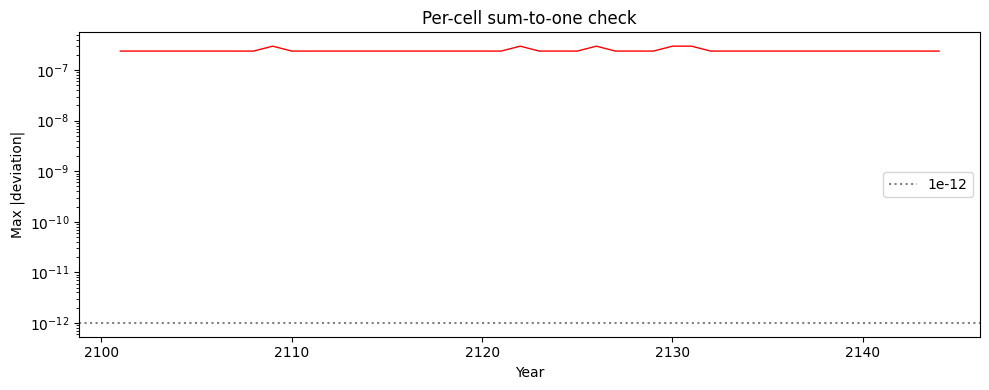

Max deviation: 2.98e-07
WARN: deviations exceed tolerance


In [17]:
cell_total_2100 = np.zeros_like(vals_2100[sc.state_vars[0]])
for v in sc.state_vars:
    cell_total_2100 += np.where(np.isfinite(vals_2100[v]), vals_2100[v], 0.0)
land_mask = np.isfinite(vals_2100[sc.residual_var])

max_dev = np.zeros(n_ramp)
for ti in range(n_ramp):
    cell_sum = np.zeros_like(vals_2100[sc.state_vars[0]])
    for v in sc.state_vars:
        cell_sum += np.where(np.isfinite(ds_ext[v].isel(time=ti).values),
                              ds_ext[v].isel(time=ti).values, 0.0)
    dev_land = np.abs(cell_sum - cell_total_2100)[land_mask]
    max_dev[ti] = np.max(dev_land)

fig, ax = plt.subplots(figsize=(10, 4))
ax.semilogy(ramp_years, max_dev, 'r-', lw=1)
ax.axhline(1e-12, color='gray', ls=':', label='1e-12')
ax.set_xlabel('Year'); ax.set_ylabel('Max |deviation|')
ax.set_title('Per-cell sum-to-one check'); ax.legend()
plt.tight_layout(); plt.show()

print(f'Max deviation: {max_dev.max():.2e}')
print(f'PASS' if max_dev.max() < 1e-10 else 'WARN: deviations exceed tolerance')

## 7. Spatial Patterns at Key Years

Mapping flux at years: [2110, 2130, 2144]
Extension data covers: 2101–2144 (44 years)
cell_area_2d: shape=(720, 1440), finite=1036800, NaN=0

Diagnostic for year 2110 (ti=9):
  forest: prev finite=1036800, curr finite=1036800
  forest: delta finite=1036800, delta range=[-0.109960, 0.039280]
  forest: flux finite=1036800, flux range=[-0.983944, 2.931711]



  2110 (ti=9): Finite=1036800, Nonzero=147232
    Flux range: [-0.9347, 2.7851], mean=0.0013, vmax=±0.1000
  2130 (ti=29): Finite=1036800, Nonzero=148727
    Flux range: [-0.2183, 1.2355], mean=0.0006, vmax=±0.1000
  2144 (ti=43): Finite=1036800, Nonzero=146793
    Flux range: [-0.0097, 0.0736], mean=0.0000, vmax=±0.1000


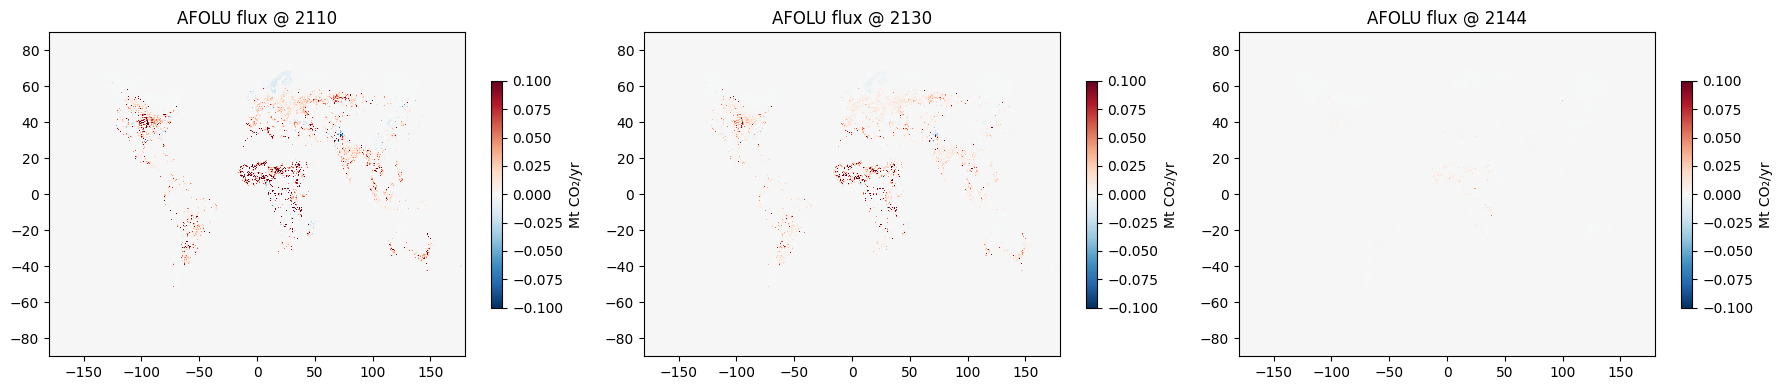

In [18]:
map_years = [2110, 2130, int(ramp_years[-1])]
fig, axes = plt.subplots(1, len(map_years), figsize=(6 * len(map_years), 4))

print(f"Mapping flux at years: {map_years}")
print(f"Extension data covers: {ramp_years[0]}–{ramp_years[-1]} ({len(ramp_years)} years)")
print(f"cell_area_2d: shape={cell_area_2d.shape}, finite={np.sum(np.isfinite(cell_area_2d))}, NaN={np.sum(np.isnan(cell_area_2d))}\n")

# Test year
test_yr = 2110
test_ti = min(np.searchsorted(ramp_years, test_yr), len(ramp_years) - 1)
print(f"Diagnostic for year {test_yr} (ti={test_ti}):")
test_v = sc.residual_var
test_prev = vals_2100[test_v] if test_ti == 0 else ds_ext[test_v].isel(time=test_ti-1).values
test_curr = ds_ext[test_v].isel(time=test_ti).values
test_delta = test_curr - test_prev
print(f"  {test_v}: prev finite={np.sum(np.isfinite(test_prev))}, curr finite={np.sum(np.isfinite(test_curr))}")
print(f"  {test_v}: delta finite={np.sum(np.isfinite(test_delta))}, delta range=[{np.nanmin(test_delta):.6f}, {np.nanmax(test_delta):.6f}]")
test_flux = -test_delta * CARBON_DENSITY[test_v] * cell_area_2d * TC_TO_MTCO2
print(f"  {test_v}: flux finite={np.sum(np.isfinite(test_flux))}, flux range=[{np.nanmin(test_flux):.6f}, {np.nanmax(test_flux):.6f}]")
print()

for ax, yr in zip(axes, map_years):
    ti = min(np.searchsorted(ramp_years, yr), len(ramp_years) - 1)
    flux_map = np.zeros((len(lat), len(lon)))
    
    for v in sc.state_vars:
        prev = vals_2100[v] if ti == 0 else ds_ext[v].isel(time=ti-1).values
        curr = ds_ext[v].isel(time=ti).values
        delta = curr - prev
        flux_contrib = -delta * CARBON_DENSITY[v] * cell_area_2d * TC_TO_MTCO2
        flux_map += np.where(np.isfinite(flux_contrib), flux_contrib, 0.0)

    # Diagnostics
    n_total = flux_map.size
    n_finite = np.sum(np.isfinite(flux_map))
    n_nonzero = np.sum(flux_map != 0)
    
    print(f"  {yr} (ti={ti}): Finite={n_finite}, Nonzero={n_nonzero}")
    
    if n_finite > 0:
        finite_flux = flux_map[np.isfinite(flux_map)]
        flux_min = np.min(finite_flux)
        flux_max = np.max(finite_flux)
        flux_mean = np.mean(finite_flux)
        vmax = np.percentile(np.abs(finite_flux), 98)
        vmax = max(vmax, 0.1)
        
        print(f"    Flux range: [{flux_min:.4f}, {flux_max:.4f}], mean={flux_mean:.4f}, vmax=±{vmax:.4f}")
    else:
        print(f"    WARNING: All values are NaN!")
        vmax = 1.0
    
    im = ax.pcolormesh(lon, lat, flux_map, cmap='RdBu_r', shading='auto',
                       vmin=-vmax, vmax=vmax)
    ax.set_title(f'AFOLU flux @ {yr}')
    plt.colorbar(im, ax=ax, shrink=0.7, label='Mt CO₂/yr')

plt.tight_layout(); plt.show()

## 8. Cumulative Emissions

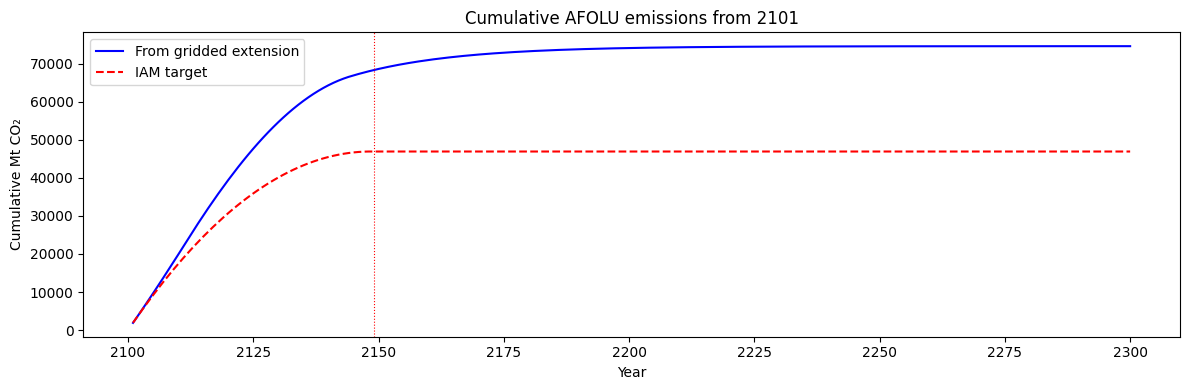

Cumulative by 2149:  gridded = 68307,  IAM = 46917 Mt CO₂
Cumulative by 2200:  gridded = 74111,  IAM = 46917 Mt CO₂


In [19]:
cum_calib = np.cumsum(ext_calib)
cum_iam = np.cumsum(iam_ext_vals)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(full_ext_years[:200], cum_calib[:200], 'b-', lw=1.5, label='From gridded extension')
ax.plot(full_ext_years[:200], cum_iam[:200], 'r--', lw=1.5, label='IAM target')
ax.axvline(cfg.YR_AFOLU_ZERO, color='r', ls=':', lw=0.8)
ax.set_xlabel('Year'); ax.set_ylabel('Cumulative Mt CO₂')
ax.set_title('Cumulative AFOLU emissions from 2101')
ax.legend()
plt.tight_layout(); plt.show()

idx_2149 = np.searchsorted(full_ext_years, 2149)
print(f'Cumulative by 2149:  gridded = {cum_calib[idx_2149]:.0f},  IAM = {cum_iam[idx_2149]:.0f} Mt CO₂')
print(f'Cumulative by 2200:  gridded = {cum_calib[99]:.0f},  IAM = {cum_iam[99]:.0f} Mt CO₂')

In [20]:
# Clean up
ds_ext.close()
ds_input.close()
print('All datasets closed.')

All datasets closed.
